In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [6]:
# 1.1 原始数据采集
print("\n1.1 原始数据采集...")
df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"原始数据形状: {df.shape}")
print(f"原始数据列名: {df.columns.tolist()}")
print(f"数据日期范围: {df['trade_date'].min()} 至 {df['trade_date'].max()}")
print(f"股票代码数量: {df['ts_code'].nunique()}")
print("\n数据前5行:")
print(df.head())



# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)


1.1 原始数据采集...
原始数据形状: (24678, 11)
原始数据列名: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']
数据日期范围: 2024-01-02 至 2025-01-10
股票代码数量: 100

数据前5行:
     ts_code  trade_date  open  high   low  close  pre_close  change  pct_chg  \
0  000005.SZ  2024-01-02  1.08  1.12  1.08   1.12       1.07    0.05   4.6729   
1  000005.SZ  2024-01-03  1.17  1.18  1.13   1.14       1.12    0.02   1.7857   
2  000005.SZ  2024-01-04  1.13  1.18  1.12   1.17       1.14    0.03   2.6316   
3  000005.SZ  2024-01-05  1.16  1.17  1.11   1.11       1.17   -0.06  -5.1282   
4  000005.SZ  2024-01-08  1.09  1.10  1.05   1.07       1.11   -0.04  -3.6036   

         vol     amount  
0   63028.00   6967.071  
1  274455.55  31989.773  
2  189486.02  21868.559  
3  151984.57  17158.063  
4   99076.57  10704.465  


In [7]:
# 剔除ST股票（根据股票代码或名称，这里假设ts_code中包含ST标识）
# 实际中可能需要根据名称判断，这里我们通过pct_chg异常值辅助判断
st_mask = df['ts_code'].str.contains('ST|st', na=False)
if st_mask.any():
    df = df[~st_mask]
    print(f"剔除ST股票后数据量: {len(df)}")
else:
    print("未发现ST股票")

# 剔除涨跌停日 (涨跌幅超过9.9%为涨跌停)
if 'pct_chg' in df.columns:
    limit_mask = (df['pct_chg'] >= 9.9) | (df['pct_chg'] <= -9.5)
    df = df[~limit_mask]
    print(f"剔除涨跌停日后数据量: {len(df)}")

# 剔除成交量或成交额为0的停牌日
if 'volume' in df.columns and 'amount' in df.columns:
    zero_mask = (df['volume'] == 0) | (df['amount'] == 0)
    df = df[~zero_mask]
    print(f"剔除停牌日后数据量: {len(df)}")

print(f"清洗后数据形状: {df.shape}")

未发现ST股票
剔除涨跌停日后数据量: 23979
清洗后数据形状: (23979, 11)


In [4]:
# 调试代码 - 查看数据列名
print("数据中的所有列名:")
print(df.columns.tolist())

# 查看是否有 'pre_close' 列
print(f"\n'pre_close' 是否在列名中: {'pre_close' in df.columns}")
print(f"'change' 是否在列名中: {'change' in df.columns}")
print(f"'pct_chg' 是否在列名中: {'pct_chg' in df.columns}")

数据中的所有列名:
['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']

'pre_close' 是否在列名中: True
'change' 是否在列名中: True
'pct_chg' 是否在列名中: True


In [8]:
# 1.3 基础衍生指标
print("\n1.3 计算基础衍生指标...")

def calculate_derived_indicators(group):
    group = group.sort_values('trade_date').copy()
    
    # 日收益率（使用前收盘价）
    if 'close' in group.columns and 'pre_close' in group.columns:
        group['daily_return'] = group['close'] / group['pre_close'] - 1
    elif 'close' in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    # 换手率（使用成交量变化率作为换手率代理）
    if 'vol' in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    # 振幅
    if 'high' in group.columns and 'low' in group.columns:
        if 'pre_close' in group.columns:
            group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
        else:
            group['amplitude'] = (group['high'] - group['low']) / group['close'].shift(1)
    
    # 成交额占比
    if 'amount' in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].sum()
    
    return group

# 方法1：使用循环保留 ts_code
print("使用循环方式计算基础衍生指标...")
unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_derived_indicators(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)

print("基础衍生指标计算完成")
print(f"新增指标: daily_return, turnover_rate, amplitude, amount_ratio")

# 检查 ts_code 是否还在
print(f"\n'ts_code' 是否在列名中: {'ts_code' in df.columns}")
print(f"数据列名: {df.columns.tolist()}")


1.3 计算基础衍生指标...
使用循环方式计算基础衍生指标...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
基础衍生指标计算完成
新增指标: daily_return, turnover_rate, amplitude, amount_ratio

'ts_code' 是否在列名中: True
数据列名: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']


In [9]:
# 调试代码 - 查看数据列名
print("数据中的所有列名:")
print(df.columns.tolist())

# 查看是否有 'pre_close' 列
print(f"\n'pre_close' 是否在列名中: {'pre_close' in df.columns}")
print(f"'change' 是否在列名中: {'change' in df.columns}")
print(f"'pct_chg' 是否在列名中: {'pct_chg' in df.columns}")

数据中的所有列名:
['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']

'pre_close' 是否在列名中: True
'change' 是否在列名中: True
'pct_chg' 是否在列名中: True


In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def fill_factor_values(series, fill_method='forward'):
    """
    根据不同因子特性填充缺失值
    fill_method: 'forward' - 前向填充, 'mean' - 均值填充, 
                 'zero' - 零填充, 'median' - 中位数填充, 'ffill_bfill' - 前后填充
    """
    # 确保输入是 Series
    if not isinstance(series, pd.Series):
        raise ValueError(f"Expected pandas Series, got {type(series)}")
    
    if fill_method == 'forward':
        return series.ffill()
    elif fill_method == 'mean':
        return series.fillna(series.mean())
    elif fill_method == 'zero':
        return series.fillna(0)
    elif fill_method == 'median':
        return series.fillna(series.median())
    elif fill_method == 'ffill_bfill':
        return series.ffill().bfill()
    else:
        return series


def calculate_technical_factors(group):
    """计算所有技术因子"""
    group = group.sort_values('trade_date').copy()
    
    # 计算基础衍生指标（如果不存在）
    if 'daily_return' not in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'turnover_rate' not in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'amplitude' not in group.columns:
        group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
    
    if 'amount_ratio' not in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    # 定义各因子的填充策略
    factor_fill_methods = {}
    
    # ---------- 价格动量类因子 ----------
    # RSI
    def calc_rsi(data, period):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    for p in [6, 12, 24]:
        col = f'rsi_{p}'
        group[col] = calc_rsi(group['close'], p)
        factor_fill_methods[col] = 'forward'
    
    # MACD
    exp1 = group['close'].ewm(span=12, adjust=False).mean()
    exp2 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = exp1 - exp2
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    factor_fill_methods['macd'] = 'forward'
    factor_fill_methods['macd_signal'] = 'forward'
    factor_fill_methods['macd_hist'] = 'forward'
    
    # MOM (动量)
    for p in [5, 10, 20]:
        col = f'mom_{p}'
        group[col] = group['close'] / group['close'].shift(p) - 1
        factor_fill_methods[col] = 'zero'
    
    # 均线偏离度
    for p in [5, 20, 60]:
        col = f'ma_dev_{p}'
        ma = group['close'].rolling(window=p).mean()
        group[col] = (group['close'] - ma) / ma
        factor_fill_methods[col] = 'forward'
    
    # ---------- 波动率类因子 ----------
    # ATR
    high_low = group['high'] - group['low']
    high_close = abs(group['high'] - group['close'].shift())
    low_close = abs(group['low'] - group['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    factor_fill_methods['atr_14'] = 'forward'
    
    # 历史波动率
    if 'daily_return' in group.columns:
        for p in [20, 60]:
            col = f'hist_vol_{p}'
            group[col] = group['daily_return'].rolling(window=p).std() * np.sqrt(252)
            factor_fill_methods[col] = 'forward'
    
    # 布林带宽度
    ma20 = group['close'].rolling(window=20).mean()
    std20 = group['close'].rolling(window=20).std()
    group['bollinger_band'] = (group['close'] - ma20) / (2 * std20)
    factor_fill_methods['bollinger_band'] = 'forward'
    
    # ---------- 成交量类因子 ----------
    # 量比VR
    for p in [5, 10]:
        col = f'vr_{p}'
        group[col] = group['vol'] / group['vol'].rolling(window=p).mean()
        factor_fill_methods[col] = 'forward'
    
    # OBV (能量潮)
    obv = np.zeros(len(group))
    for i in range(1, len(group)):
        if group['close'].iloc[i] > group['close'].iloc[i-1]:
            obv[i] = obv[i-1] + group['vol'].iloc[i]
        elif group['close'].iloc[i] < group['close'].iloc[i-1]:
            obv[i] = obv[i-1] - group['vol'].iloc[i]
        else:
            obv[i] = obv[i-1]
    group['obv'] = obv
    factor_fill_methods['obv'] = 'forward'
    
    # 量价相关系数
    group['volume_price_corr'] = group['vol'].rolling(window=20).corr(group['close'])
    factor_fill_methods['volume_price_corr'] = 'zero'
    
    # ---------- 价格形态类因子 ----------
    # 最高最低相对位置
    high_20 = group['high'].rolling(window=20).max()
    low_20 = group['low'].rolling(window=20).min()
    group['highest_lowest_pos'] = (group['close'] - low_20) / (high_20 - low_20)
    factor_fill_methods['highest_lowest_pos'] = 'forward'
    
    # 上下影线比例
    group['upper_shadow'] = (group['high'] - group[['open', 'close']].max(axis=1)) / (group['high'] - group['low'])
    group['lower_shadow'] = (group[['open', 'close']].min(axis=1) - group['low']) / (group['high'] - group['low'])
    factor_fill_methods['upper_shadow'] = 'forward'
    factor_fill_methods['lower_shadow'] = 'forward'
    
    # 实体比例
    group['body_ratio'] = abs(group['close'] - group['open']) / (group['high'] - group['low'])
    factor_fill_methods['body_ratio'] = 'forward'
    
    # ---------- 流动性类因子 ----------
    # Amihud非流动性指标
    group['amihud'] = abs(group['daily_return']) / (group['amount'] * 1e6)
    factor_fill_methods['amihud'] = 'median'
    
    # 成交额规模代理（对数成交额）
    group['log_amount'] = np.log(group['amount'] + 1)
    factor_fill_methods['log_amount'] = 'forward'
    
    # 应用填充策略
    for col, method in factor_fill_methods.items():
        if col in group.columns:
            # 先处理无穷值
            group[col] = group[col].replace([np.inf, -np.inf], np.nan)
            
            # 应用填充方法 - 直接传入 Series
            try:
                filled_series = fill_factor_values(group[col], method)
                group[col] = filled_series
            except Exception as e:
                print(f"  填充 {col} 时出错: {e}")
                # 使用简单的向前填充作为备选
                group[col] = group[col].ffill().fillna(0)
            
            # 再次确保没有NaN（兜底）
            if group[col].isna().any():
                group[col] = group[col].ffill().bfill().fillna(0)
    
    return group


print("\n" + "="*60)
print("2.1 计算技术因子")
print("="*60)

# 检查 df 是否存在
try:
    if 'df' not in locals() or df is None or len(df) == 0:
        print("错误: df 不存在或为空，请先加载数据")
        # 尝试重新加载数据
        import os
        data_file = os.path.join(os.path.dirname(os.path.abspath('__file__')), 
                                 'extracted_data', 'stk_100.csv')
        if os.path.exists(data_file):
            df = pd.read_csv(data_file)
            print(f"从 {data_file} 重新加载数据")
        else:
            print("请先运行数据加载代码")
            raise ValueError("df 未定义")
except NameError:
    print("错误: df 未定义，请先加载数据")
    raise

# 检查必要的列是否存在
required_cols = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"错误: 缺少必要的列: {missing_cols}")
    print(f"当前列: {df.columns.tolist()}")
else:
    # 确保日期是字符串格式
    if df['trade_date'].dtype == 'datetime64[ns]':
        df['trade_date'] = df['trade_date'].dt.strftime('%Y-%m-%d')
    
    # 使用循环方式计算技术因子
    print("使用循环方式计算技术因子...")
    unique_codes = df['ts_code'].unique().tolist()
    print(f"共 {len(unique_codes)} 只股票")
    
    df_list = []
    error_count = 0
    for i, code in enumerate(unique_codes):
        if i % 10 == 0:
            print(f"  处理进度: {i}/{len(unique_codes)}")
        
        try:
            group = df[df['ts_code'] == code].copy()
            group = calculate_technical_factors(group)
            df_list.append(group)
        except Exception as e:
            print(f"  处理 {code} 时出错: {e}")
            error_count += 1
            continue
    
    if df_list:
        df = pd.concat(df_list, ignore_index=True)
        print(f"✅ 技术因子计算完成，共处理 {len(df_list)} 只股票")
        if error_count > 0:
            print(f"⚠️ 有 {error_count} 只股票处理失败")
    else:
        print("❌ 没有成功处理任何股票")
        raise ValueError("所有股票处理失败")

# 识别因子列（排除基础列）
base_cols = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
             'vol', 'amount', 'pre_close', 'change', 'pct_chg']

# 添加可能存在的衍生列
derived_cols = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
all_base_cols = base_cols + derived_cols

factor_columns = [col for col in df.columns if col not in all_base_cols]
print(f"\n📊 技术因子计算完成，共 {len(factor_columns)} 个因子")

# 显示前20个因子
print(f"因子列表 (前20个): {factor_columns[:20]}")

# 检查因子是否有缺失值
print("\n检查因子缺失值情况:")
has_missing = False
checked_count = 0
for col in factor_columns:
    if checked_count >= 20:  # 只检查前20个
        break
    nan_count = df[col].isna().sum()
    inf_count = np.isinf(df[col]).sum() if col in df.columns else 0
    if nan_count > 0 or inf_count > 0:
        print(f"  {col}: NaN={nan_count}, Inf={inf_count}")
        has_missing = True
    checked_count += 1

if not has_missing and len(factor_columns) > 0:
    print("  ✅ 前20个因子均无缺失值！")

# 显示因子统计信息
print("\n因子统计信息 (前5个因子):")
if factor_columns:
    try:
        print(df[factor_columns[:5]].describe())
    except Exception as e:
        print(f"无法显示统计信息: {e}")

print("\n" + "="*60)
print("技术因子计算完成！")
print("="*60)


2.1 计算技术因子
使用循环方式计算技术因子...
共 100 只股票
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 技术因子计算完成，共处理 100 只股票

📊 技术因子计算完成，共 26 个因子
因子列表 (前20个): ['rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'mom_5', 'mom_10', 'mom_20', 'ma_dev_5', 'ma_dev_20', 'ma_dev_60', 'atr_14', 'hist_vol_20', 'hist_vol_60', 'bollinger_band', 'vr_5', 'vr_10', 'obv', 'volume_price_corr']

检查因子缺失值情况:
  ✅ 前20个因子均无缺失值！

因子统计信息 (前5个因子):
              rsi_6        rsi_12        rsi_24          macd   macd_signal
count  23979.000000  23979.000000  23979.000000  23979.000000  23979.000000
mean      46.649805     46.894409     46.912291     -0.059136     -0.054034
std       25.568152     18.524729     14.679516      1.159935      1.078740
min        0.000000      0.000000      3.818616    -15.683907    -12.532720
25%       26.796748     33.048148     37.003732     -0.274829     -0.252195
50%       45.45454

In [13]:
# 2.2 因子预处理
from sklearn.linear_model import LinearRegression
print("\n2.2 因子预处理...")

# 提取因子数据
factor_data = df[factor_columns].copy()

# 确保没有NaN和无穷值
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

# MAD去极值
def mad_winsorize(data, n_sigma=5):
    """MAD去极值"""
    median = data.median()
    mad = (data - median).abs().median()
    upper_bound = median + n_sigma * mad
    lower_bound = median - n_sigma * mad
    return data.clip(lower_bound, upper_bound)

print("进行MAD去极值处理...")
for col in factor_columns:
    factor_data[col] = mad_winsorize(factor_data[col])

# Z-score标准化
print("进行Z-score标准化...")
scaler = StandardScaler()
factor_data_scaled = pd.DataFrame(scaler.fit_transform(factor_data), 
                                  columns=factor_columns, 
                                  index=factor_data.index)

# 规模中性化（使用成交额对数作为规模代理变量）
print("进行规模中性化...")
log_amount = df['log_amount'].values.reshape(-1, 1)
factor_neutralized = pd.DataFrame(index=factor_data.index, columns=factor_columns)

for col in factor_columns:
    # 对每个因子回归取残差
    reg = LinearRegression()
    reg.fit(log_amount, factor_data_scaled[col].values.reshape(-1, 1))
    residual = factor_data_scaled[col].values - reg.predict(log_amount).flatten()
    factor_neutralized[col] = residual

print("因子预处理完成")

# 将预处理后的因子合并回原始数据
for col in factor_columns:
    df[f'{col}_processed'] = factor_neutralized[col]

print("\n因子预处理后统计:")
print(factor_neutralized.describe())

# 验证 ts_code 仍然存在
print(f"\n最终数据列数: {len(df.columns)}")
print(f"'ts_code' 是否在列名中: {'ts_code' in df.columns}")
if 'ts_code' in df.columns:
    print(f"股票代码数量: {df['ts_code'].nunique()}")

print("\n" + "="*80)
print("数据准备和因子计算阶段完成！")
print("="*80)


2.2 因子预处理...
进行MAD去极值处理...
进行Z-score标准化...
进行规模中性化...
因子预处理完成

因子预处理后统计:
              rsi_6        rsi_12        rsi_24          macd   macd_signal  \
count  2.397900e+04  2.397900e+04  2.397900e+04  2.397900e+04  2.397900e+04   
mean  -1.220833e-16 -3.318770e-16 -3.206169e-16 -2.631311e-16 -1.374919e-16   
std    9.833828e-01  9.725450e-01  9.621014e-01  9.603418e-01  9.628043e-01   
min   -2.289736e+00 -2.848386e+00 -3.134080e+00 -2.770250e+00 -2.846212e+00   
25%   -7.393844e-01 -7.043925e-01 -6.310203e-01 -4.010834e-01 -3.997972e-01   
50%   -3.577635e-02  1.416007e-02  7.594975e-02  6.255296e-02  5.531050e-02   
75%    7.186722e-01  7.166748e-01  7.000028e-01  4.576251e-01  4.514760e-01   
max    2.650705e+00  3.103426e+00  2.866964e+00  2.539996e+00  2.574873e+00   

          macd_hist         mom_5        mom_10        mom_20      ma_dev_5  \
count  2.397900e+04  2.397900e+04  2.397900e+04  2.397900e+04  2.397900e+04   
mean  -1.137864e-16 -1.558637e-16 -2.026820e-16 -4.05364

创建输出文件夹: output1

计算未来5日收益...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
未来5日收益计算完成

3.1 IC/IR分析...
待检验因子数量: 26
计算IC值...
  处理进度: 0/26
  处理进度: 20/26

因子IC值排名 (Top 20):
                          factor        ic    ic_abs
14         hist_vol_60_processed -0.073062  0.073062
13         hist_vol_20_processed  0.072586  0.072586
1               rsi_12_processed  0.061580  0.061580
20  highest_lowest_pos_processed  0.059101  0.059101
10           ma_dev_20_processed  0.052310  0.052310
2               rsi_24_processed  0.045192  0.045192
8               mom_20_processed -0.040965  0.040965
24              amihud_processed  0.039276  0.039276
15      bollinger_band_processed  0.038444  0.038444
5            macd_hist_processed  0.036761  0.036761
6                mom_5_processed -0.035519  0.035519
18                 obv_processed -0.026493  0.026493
4          macd_signal_processed -0.02

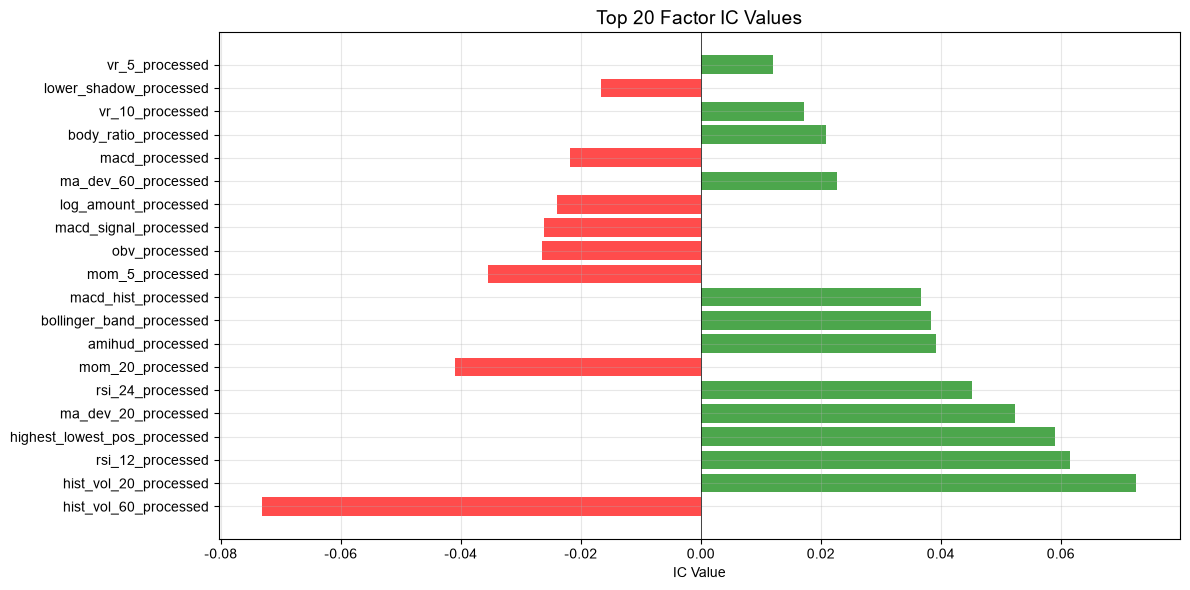

因子IC值图已保存到: output1/factor_ic_values.png


In [15]:
import os
output_dir = 'output1'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"创建输出文件夹: {output_dir}")
# 计算未来5日收益
def calculate_future_returns(group):
    group = group.sort_values('trade_date').copy()
    group['future_5d_return'] = group['close'].shift(-5) / group['close'] - 1
    return group

print("\n计算未来5日收益...")
unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_future_returns(group)
    df_list.append(group)
df = pd.concat(df_list, ignore_index=True)
print("未来5日收益计算完成")

# 3.1 IC/IR分析
print("\n3.1 IC/IR分析...")

# 获取因子列
factor_columns = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                                                           'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                                                           'daily_return', 'turnover_rate', 'amplitude', 
                                                           'amount_ratio', 'future_5d_return']]
factor_cols_processed = [f'{col}_processed' for col in factor_columns if f'{col}_processed' in df.columns]

print(f"待检验因子数量: {len(factor_cols_processed)}")

ic_results = []
print("计算IC值...")
for idx, col in enumerate(factor_cols_processed):
    if idx % 20 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    # 计算Spearman相关系数
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
        if not np.isnan(ic):
            ic_results.append({
                'factor': col,
                'ic': ic,
                'ic_abs': abs(ic)
            })

if len(ic_results) > 0:
    ic_df = pd.DataFrame(ic_results).sort_values('ic_abs', ascending=False)
    print("\n因子IC值排名 (Top 20):")
    print(ic_df.head(20))
    
    # 保存IC结果到CSV
    ic_df.to_csv(os.path.join(output_dir, 'factor_ic_analysis.csv'), index=False)
    print(f"IC分析结果已保存到: {output_dir}/factor_ic_analysis.csv")
    
    # 绘制IC值分布
    fig, ax = plt.subplots(figsize=(12, 6))
    top_ic = ic_df.head(20)
    colors = ['green' if x > 0 else 'red' for x in top_ic['ic']]
    ax.barh(top_ic['factor'], top_ic['ic'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('IC Value')
    ax.set_title('Top 20 Factor IC Values', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_ic_values.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"因子IC值图已保存到: {output_dir}/factor_ic_values.png")
else:
    print("没有有效的IC计算结果")
    ic_df = pd.DataFrame()


3.2 分组单调性测试...
测试因子单调性...
  处理进度: 0/26
  处理进度: 10/26
  处理进度: 20/26

因子单调性测试结果:
                          factor  monotonicity  is_monotonic
0                rsi_6_processed           0.0         False
1               rsi_12_processed           1.0          True
2               rsi_24_processed           0.1         False
3                 macd_processed          -0.3         False
4          macd_signal_processed          -0.1         False
5            macd_hist_processed           0.8          True
6                mom_5_processed          -0.1         False
7               mom_10_processed           0.7         False
8               mom_20_processed          -0.3         False
9             ma_dev_5_processed           0.4         False
10           ma_dev_20_processed           1.0          True
11           ma_dev_60_processed           0.5         False
12              atr_14_processed           0.3         False
13         hist_vol_20_processed           0.6         False
14   

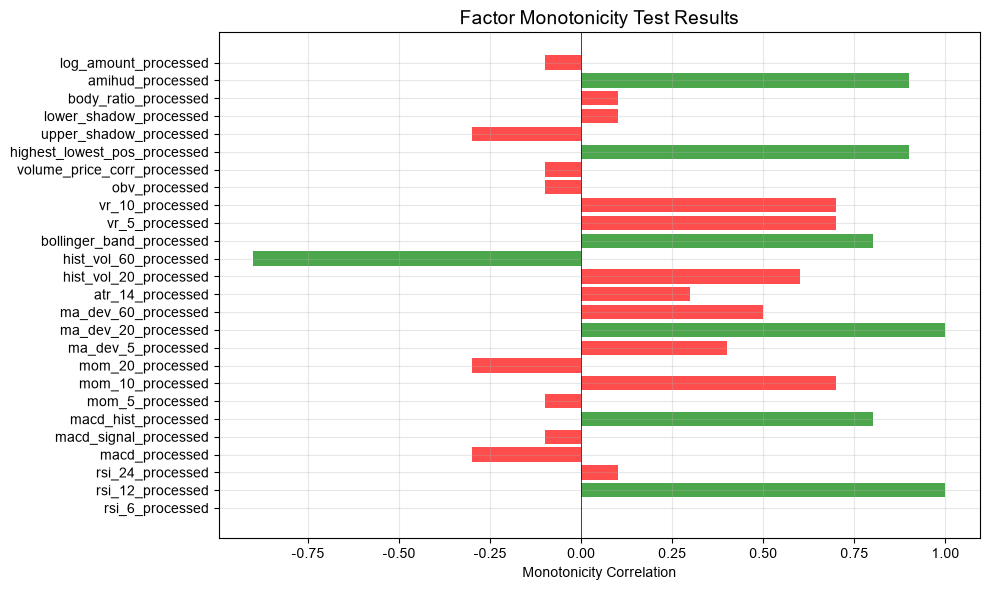

因子单调性图已保存到: output1/factor_monotonicity.png


In [16]:
# 3.2 分组单调性测试
print("\n3.2 分组单调性测试...")

def test_monotonicity(factor_col):
    """测试因子分组的单调性"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < 50:
        return None
    
    try:
        # 分成5组
        valid_data['group'] = pd.qcut(valid_data[factor_col], q=5, labels=False, duplicates='drop')
        if len(valid_data['group'].unique()) < 3:
            return None
        group_returns = valid_data.groupby('group')['future_5d_return'].mean()
        
        # 检查是否单调（使用Spearman相关系数）
        if len(group_returns) >= 3:
            monotonic_corr = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
            return monotonic_corr
    except:
        return None
    return None

monotonic_results = []
print("测试因子单调性...")
for idx, col in enumerate(factor_cols_processed[:30]):  # 测试前30个因子
    if idx % 10 == 0:
        print(f"  处理进度: {idx}/{min(30, len(factor_cols_processed))}")
    mono_corr = test_monotonicity(col)
    if mono_corr is not None and not np.isnan(mono_corr):
        monotonic_results.append({
            'factor': col,
            'monotonicity': mono_corr,
            'is_monotonic': abs(mono_corr) > 0.7
        })

if len(monotonic_results) > 0:
    monotonic_df = pd.DataFrame(monotonic_results)
    print("\n因子单调性测试结果:")
    print(monotonic_df)
    
    # 保存单调性结果到CSV
    monotonic_df.to_csv(os.path.join(output_dir, 'factor_monotonicity.csv'), index=False)
    print(f"单调性测试结果已保存到: {output_dir}/factor_monotonicity.csv")
    
    # 绘制单调性结果
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if x else 'red' for x in monotonic_df['is_monotonic']]
    ax.barh(monotonic_df['factor'], monotonic_df['monotonicity'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Monotonicity Correlation')
    ax.set_title('Factor Monotonicity Test Results', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_monotonicity.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"因子单调性图已保存到: {output_dir}/factor_monotonicity.png")
else:
    print("没有有效的单调性测试结果")


3.3 因子筛选...
计算因子IR值...
  处理进度: 0/26
  处理进度: 20/26

因子IR值排名 (Top 20):
                          factor        ir
23          body_ratio_processed  0.191061
13         hist_vol_20_processed  0.180633
12              atr_14_processed  0.157221
24              amihud_processed  0.049672
14         hist_vol_60_processed  0.017730
16                vr_5_processed -0.018640
17               vr_10_processed -0.061032
21        upper_shadow_processed -0.089212
22        lower_shadow_processed -0.143112
19   volume_price_corr_processed -0.165440
4          macd_signal_processed -0.233039
18                 obv_processed -0.336795
25          log_amount_processed -0.498113
3                 macd_processed -0.607370
11           ma_dev_60_processed -0.758486
5            macd_hist_processed -0.814717
2               rsi_24_processed -0.814875
8               mom_20_processed -0.834793
20  highest_lowest_pos_processed -0.843315
9             ma_dev_5_processed -0.884670
IR分析结果已保存到: output1/factor_

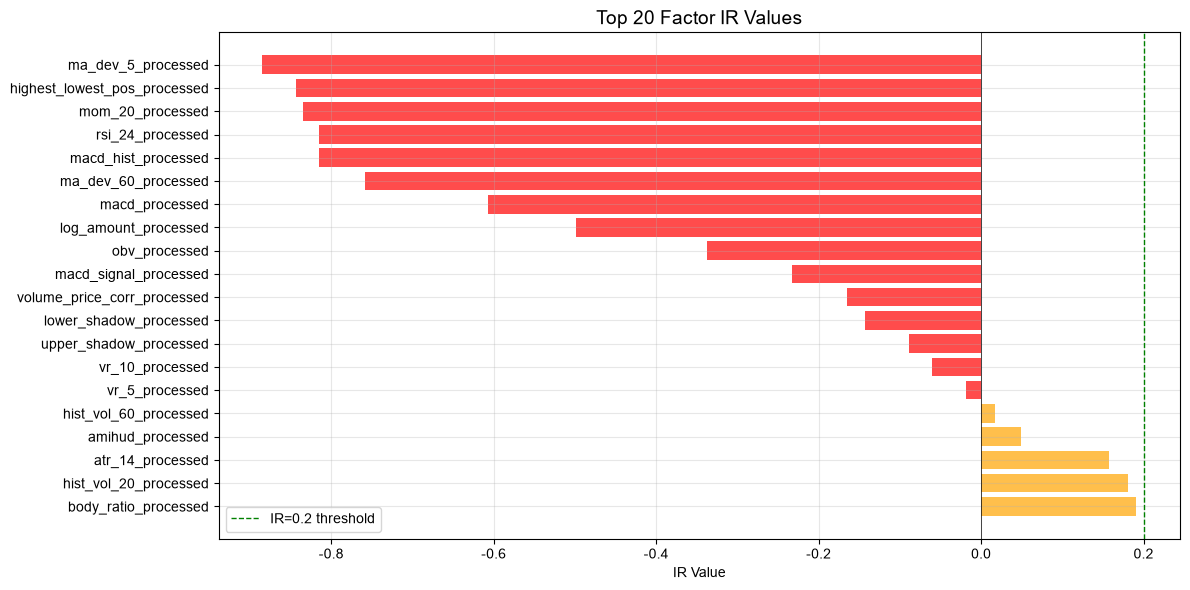

因子IR值图已保存到: output1/factor_ir_values.png

筛选出IR > 0.2的因子: 0个
没有因子IR > 0.2，使用IR排名前10的因子

检查因子相关性，剔除冗余因子...
相关性矩阵已保存到: output1/factor_correlation_matrix.csv


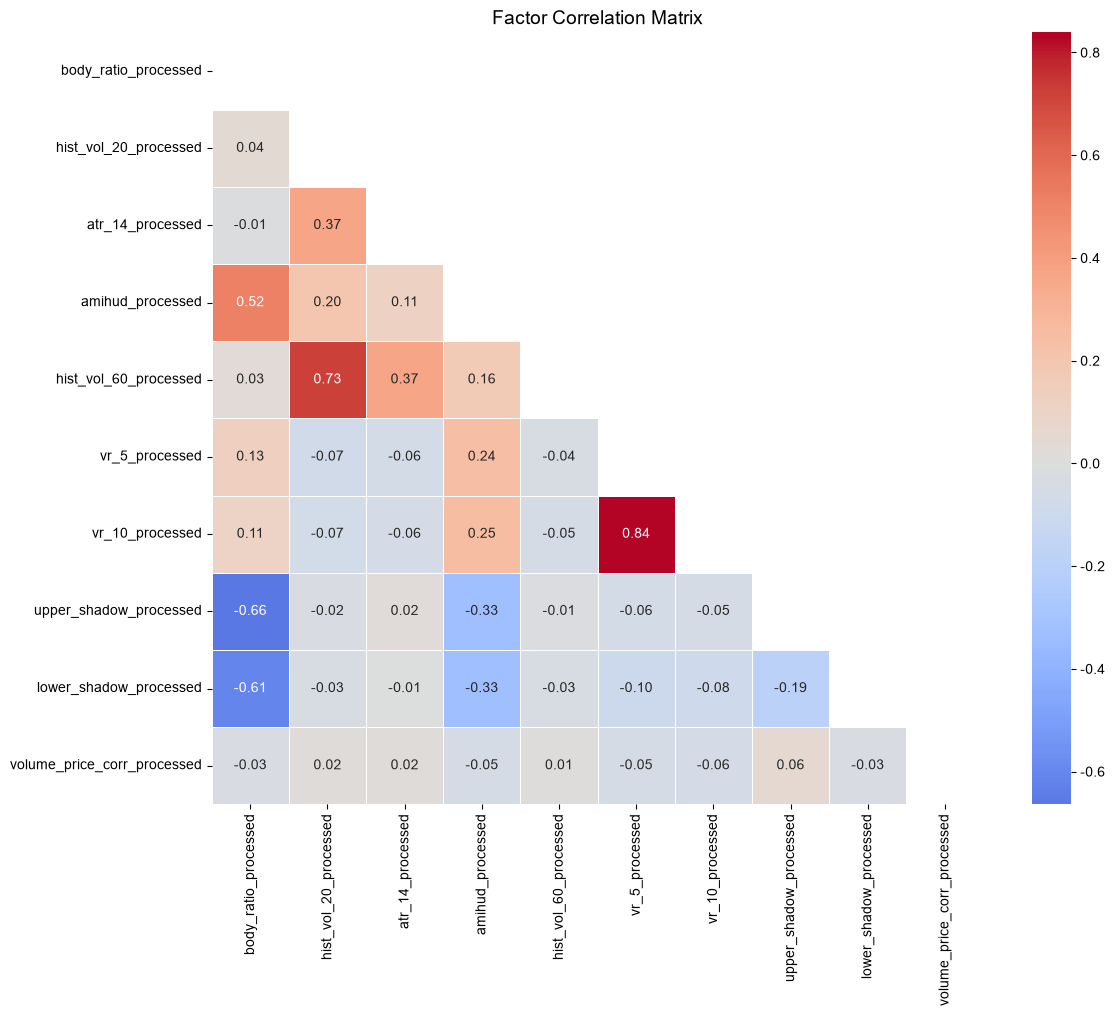

因子相关性热力图已保存到: output1/factor_correlation.png
发现 2 对高相关性因子 (>0.7)

最终选择的因子: 8个
['body_ratio_processed', 'hist_vol_20_processed', 'atr_14_processed', 'amihud_processed', 'vr_5_processed', 'upper_shadow_processed', 'lower_shadow_processed', 'volume_price_corr_processed']
最终选择的因子列表已保存到: output1/final_selected_factors.csv


In [17]:
# 3.3 因子筛选
print("\n3.3 因子筛选...")

# 计算IR (IC的均值/标准差)
def calculate_ir(factor_col, window=20):
    """计算因子的IR"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < window:
        return 0
    
    # 计算滚动IC
    ic_series = []
    for i in range(window, len(valid_data)):
        sub_data = valid_data.iloc[i-window:i]
        if len(sub_data) > 10:
            ic = stats.spearmanr(sub_data[factor_col], sub_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_series.append(ic)
    
    if len(ic_series) > 0:
        ir = np.mean(ic_series) / (np.std(ic_series) + 1e-6)
        return ir
    return 0

# 计算每个因子的IR
print("计算因子IR值...")
ir_results = []
for idx, col in enumerate(factor_cols_processed):
    if idx % 20 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    ir = calculate_ir(col)
    if ir != 0:
        ir_results.append({
            'factor': col,
            'ir': ir
        })

if len(ir_results) > 0:
    ir_df = pd.DataFrame(ir_results).sort_values('ir', ascending=False)
    print("\n因子IR值排名 (Top 20):")
    print(ir_df.head(20))
    
    # 保存IR结果到CSV
    ir_df.to_csv(os.path.join(output_dir, 'factor_ir_analysis.csv'), index=False)
    print(f"IR分析结果已保存到: {output_dir}/factor_ir_analysis.csv")
    
    # 绘制IR值分布
    fig, ax = plt.subplots(figsize=(12, 6))
    top_ir = ir_df.head(20)
    colors = ['green' if x > 0.2 else 'orange' if x > 0 else 'red' for x in top_ir['ir']]
    ax.barh(top_ir['factor'], top_ir['ir'], color=colors, alpha=0.7)
    ax.axvline(x=0.2, color='green', linestyle='--', linewidth=1, label='IR=0.2 threshold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('IR Value')
    ax.set_title('Top 20 Factor IR Values', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_ir_values.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"因子IR值图已保存到: {output_dir}/factor_ir_values.png")
    
    # 筛选IR > 0.2的因子
    selected_factors = ir_df[ir_df['ir'] > 0.2]['factor'].tolist()
    print(f"\n筛选出IR > 0.2的因子: {len(selected_factors)}个")
    if len(selected_factors) > 0:
        print(selected_factors)
    else:
        print("没有因子IR > 0.2，使用IR排名前10的因子")
        selected_factors = ir_df.head(10)['factor'].tolist()
else:
    print("无法计算IR值，使用所有因子")
    selected_factors = factor_cols_processed[:10]

# 剔除相关性>0.7的冗余因子
if len(selected_factors) > 1:
    print("\n检查因子相关性，剔除冗余因子...")
    # 获取原始因子数据
    factor_data_for_corr = df[selected_factors].copy()
    factor_corr = factor_data_for_corr.corr()
    
    # 保存相关性矩阵到CSV
    factor_corr.to_csv(os.path.join(output_dir, 'factor_correlation_matrix.csv'))
    print(f"相关性矩阵已保存到: {output_dir}/factor_correlation_matrix.csv")
    
    # 绘制相关性热力图
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(factor_corr, dtype=bool))
    sns.heatmap(factor_corr, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, 
                linewidths=0.5, ax=ax)
    ax.set_title('Factor Correlation Matrix', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'factor_correlation.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"因子相关性热力图已保存到: {output_dir}/factor_correlation.png")
    
    # 找出高相关因子对
    high_corr_pairs = []
    for i in range(len(selected_factors)):
        for j in range(i+1, len(selected_factors)):
            if abs(factor_corr.iloc[i, j]) > 0.7:
                high_corr_pairs.append((selected_factors[i], selected_factors[j], factor_corr.iloc[i, j]))
    
    print(f"发现 {len(high_corr_pairs)} 对高相关性因子 (>0.7)")
    
    # 剔除冗余因子（保留IR较高的）
    to_remove = set()
    for pair in high_corr_pairs:
        # 比较两个因子的IR，剔除IR较低的
        if len(ir_results) > 0:
            ir1 = ir_df[ir_df['factor'] == pair[0]]['ir'].values
            ir2 = ir_df[ir_df['factor'] == pair[1]]['ir'].values
            if len(ir1) > 0 and len(ir2) > 0:
                if ir1[0] < ir2[0]:
                    to_remove.add(pair[0])
                else:
                    to_remove.add(pair[1])
    
    final_factors = [f for f in selected_factors if f not in to_remove]
else:
    final_factors = selected_factors

print(f"\n最终选择的因子: {len(final_factors)}个")
print(final_factors)

# 保存最终选择的因子到CSV
pd.DataFrame({'selected_factors': final_factors}).to_csv(
    os.path.join(output_dir, 'final_selected_factors.csv'), index=False)
print(f"最终选择的因子列表已保存到: {output_dir}/final_selected_factors.csv")

In [18]:
# 4.1 因子加权
print("\n4.1 因子加权...")

if len(ir_results) > 0:
    # IR加权
    ir_weights = ir_df[ir_df['factor'].isin(final_factors)].set_index('factor')['ir']
    if len(ir_weights) > 0:
        ir_weights = ir_weights / ir_weights.sum()
        print("\nIR加权权重:")
        print(ir_weights)
    else:
        ir_weights = pd.Series(1/len(final_factors), index=final_factors)
        print("\n使用等权替代:")
        print(ir_weights)
else:
    ir_weights = pd.Series(1/len(final_factors), index=final_factors)
    print("\n使用等权:")
    print(ir_weights)

# 等权
equal_weights = pd.Series(1/len(final_factors), index=final_factors)
print("\n等权权重:")
print(equal_weights)

# 保存权重到CSV
weights_df = pd.DataFrame({
    'factor': ir_weights.index,
    'ir_weight': ir_weights.values,
    'equal_weight': equal_weights.values
})
weights_df.to_csv(os.path.join(output_dir, 'factor_weights.csv'), index=False)
print(f"因子权重已保存到: {output_dir}/factor_weights.csv")

# 合成综合因子
def composite_score(data, weights):
    """计算综合因子得分"""
    score = np.zeros(len(data))
    for factor, weight in weights.items():
        if factor in data.columns:
            score += data[factor].values * weight
    return score

# 使用IR加权
df['composite_score_ir'] = composite_score(df, ir_weights)

# 使用等权
df['composite_score_equal'] = composite_score(df, equal_weights)

print("\n综合因子得分统计:")
print(df[['composite_score_ir', 'composite_score_equal']].describe())


4.1 因子加权...

IR加权权重:
factor
body_ratio_processed           1.178059
hist_vol_20_processed          1.113762
atr_14_processed               0.969403
amihud_processed               0.306272
vr_5_processed                -0.114931
upper_shadow_processed        -0.550068
lower_shadow_processed        -0.882413
volume_price_corr_processed   -1.020083
Name: ir, dtype: float64

等权权重:
body_ratio_processed           0.125
hist_vol_20_processed          0.125
atr_14_processed               0.125
amihud_processed               0.125
vr_5_processed                 0.125
upper_shadow_processed         0.125
lower_shadow_processed         0.125
volume_price_corr_processed    0.125
dtype: float64
因子权重已保存到: output1/factor_weights.csv

综合因子得分统计:
       composite_score_ir  composite_score_equal
count        2.397900e+04           2.397900e+04
mean         1.896440e-16          -4.029935e-17
std          3.021756e+00           2.883759e-01
min         -8.689458e+00          -8.936759e-01
25%         -2.

In [19]:
# 4.2 行业风险控制（K-means聚类）
print("\n4.2 K-means聚类控制行业风险...")

# 基于量价特征进行聚类
cluster_features = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
cluster_data = df[cluster_features].fillna(0)

# 处理无穷值
cluster_data = cluster_data.replace([np.inf, -np.inf], 0)

# 标准化
cluster_scaler = StandardScaler()
cluster_data_scaled = cluster_scaler.fit_transform(cluster_data)

# K-means聚类
n_clusters = min(10, max(2, df['ts_code'].nunique() // 10))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_data_scaled)

print(f"将股票分为 {n_clusters} 个聚类")
print("各聚类样本数:")
print(df['cluster'].value_counts().sort_index())


4.2 K-means聚类控制行业风险...
将股票分为 10 个聚类
各聚类样本数:
cluster
0     550
1    4093
2      57
3    8168
4     526
5    2023
6    4580
7    2448
8    1244
9     290
Name: count, dtype: int64


In [20]:
# 4.3 选股策略
print("\n4.3 Top 30选股策略...")

# 初始化回测数据
df['selected_ir'] = 0
df['selected_equal'] = 0

# 按调仓日分组（每月调仓）
df['year_month'] = df['trade_date'].dt.to_period('M')

print("开始选股...")
for date, group in df.groupby('year_month'):
    if len(group) < 30:
        continue
    
    # 限制每个聚类最多30%
    cluster_limit = max(1, int(0.3 * 30))
    
    selected_stocks_ir = []
    selected_stocks_equal = []
    
    for cluster in group['cluster'].unique():
        cluster_group = group[group['cluster'] == cluster]
        # 选择该聚类中得分最高的股票
        top_n_ir = min(cluster_limit, len(cluster_group))
        top_n_equal = min(cluster_limit, len(cluster_group))
        
        top_ir = cluster_group.nlargest(top_n_ir, 'composite_score_ir')
        top_equal = cluster_group.nlargest(top_n_equal, 'composite_score_equal')
        
        selected_stocks_ir.extend(top_ir.index.tolist())
        selected_stocks_equal.extend(top_equal.index.tolist())
    
    # 如果选股不足30，从剩余股票中补充
    if len(selected_stocks_ir) < 30:
        remaining = group[~group.index.isin(selected_stocks_ir)]
        if len(remaining) > 0:
            additional = remaining.nlargest(30 - len(selected_stocks_ir), 'composite_score_ir')
            selected_stocks_ir.extend(additional.index.tolist())
    
    if len(selected_stocks_equal) < 30:
        remaining = group[~group.index.isin(selected_stocks_equal)]
        if len(remaining) > 0:
            additional = remaining.nlargest(30 - len(selected_stocks_equal), 'composite_score_equal')
            selected_stocks_equal.extend(additional.index.tolist())
    
    # 标记选中的股票
    if len(selected_stocks_ir) > 0:
        df.loc[selected_stocks_ir, 'selected_ir'] = 1
    if len(selected_stocks_equal) > 0:
        df.loc[selected_stocks_equal, 'selected_equal'] = 1

print("选股完成")
print(f"IR策略选中记录数: {df['selected_ir'].sum()}")
print(f"等权策略选中记录数: {df['selected_equal'].sum()}")


4.3 Top 30选股策略...
开始选股...
选股完成
IR策略选中记录数: 1062
等权策略选中记录数: 1062



5. 策略回测与绩效评估

5.1 IR加权策略回测...

selected_ir 绩效指标:
总收益率: 259.47%
年化收益率: 283.22%
年化波动率: 58.86%
夏普比率: 4.8118
最大回撤: -27.73%
胜率: 56.25%

5.2 等权策略回测...

selected_equal 绩效指标:
总收益率: 158.58%
年化收益率: 164.65%
年化波动率: 49.16%
夏普比率: 3.3493
最大回撤: -29.17%
胜率: 60.16%
绩效指标已保存到: output1/performance_metrics.csv


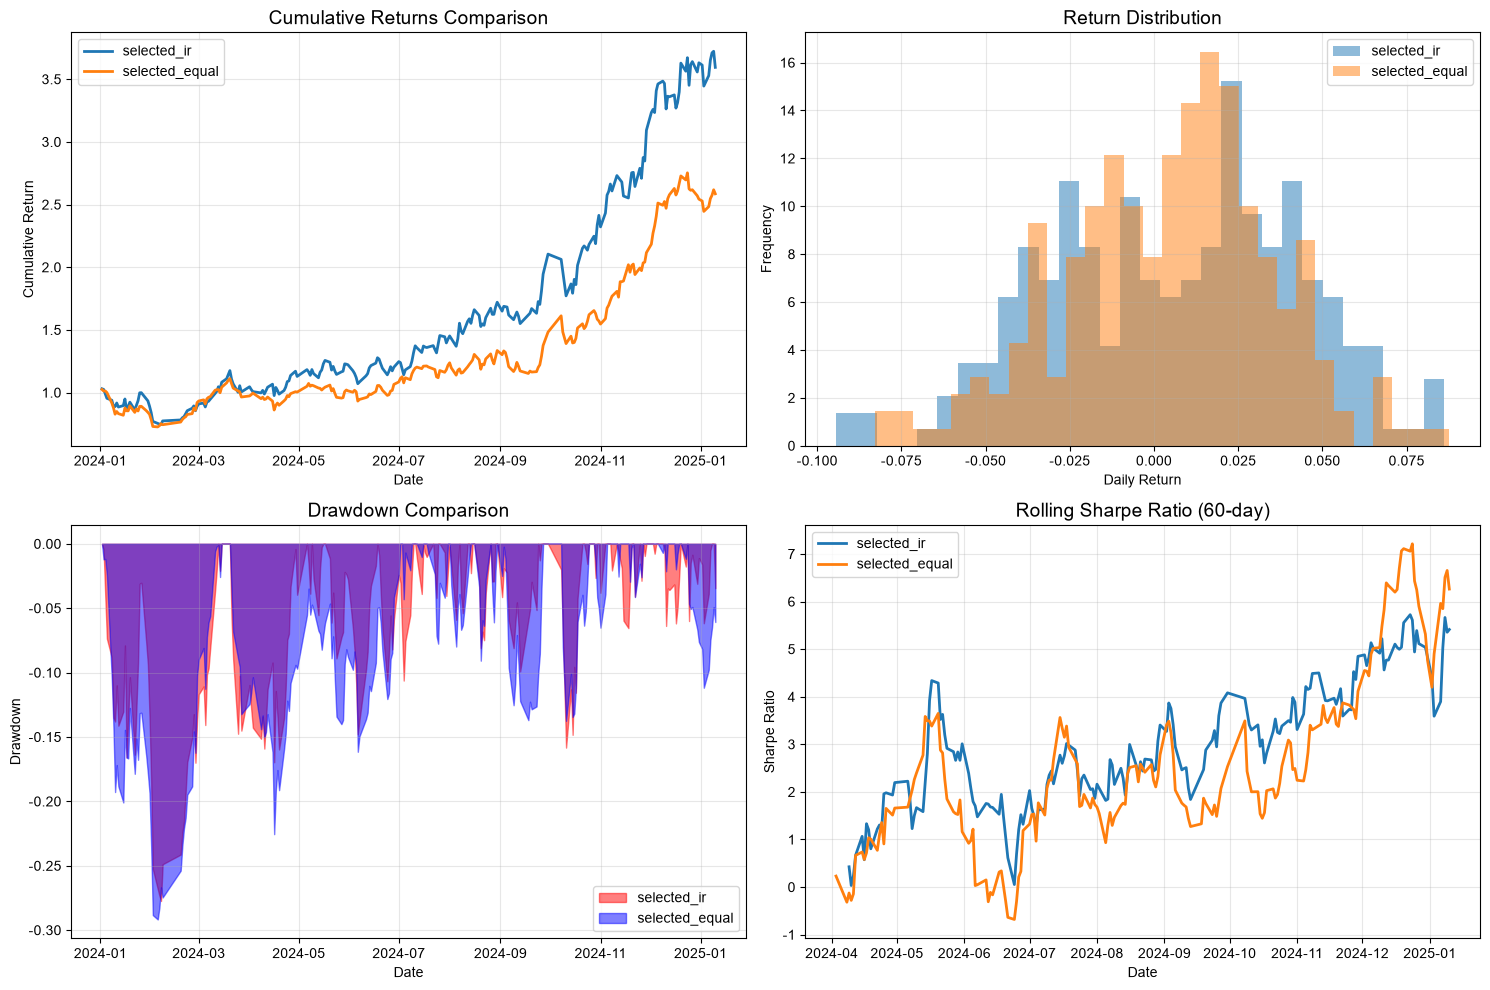

回测图表已保存到: output1/backtest_results.png


In [22]:
# ==================== 5. 策略回测与绩效评估 ====================
print("\n" + "="*80)
print("5. 策略回测与绩效评估")
print("="*80)

def backtest_strategy(df, selected_col, strategy_name):
    """回测策略"""
    # 计算每日组合收益（等权）
    daily_returns = []
    dates = []
    
    for date in df['trade_date'].unique():
        day_data = df[df['trade_date'] == date]
        selected = day_data[day_data[selected_col] == 1]
        if len(selected) > 0:
            # 等权组合收益
            avg_return = selected['daily_return'].mean()
            if not np.isnan(avg_return):
                daily_returns.append(avg_return)
                dates.append(date)
    
    if len(daily_returns) == 0:
        print(f"{strategy_name} 没有交易记录")
        return None, None, None
    
    # 转换为时间序列
    returns_series = pd.Series(daily_returns, index=pd.to_datetime(dates))
    returns_series = returns_series.sort_index()
    
    # 计算累积收益
    cumulative_returns = (1 + returns_series).cumprod()
    
    # 计算绩效指标
    total_return = cumulative_returns.iloc[-1] - 1 if len(cumulative_returns) > 0 else 0
    annual_return = (1 + total_return) ** (252 / len(returns_series)) - 1 if len(returns_series) > 0 else 0
    volatility = returns_series.std() * np.sqrt(252) if len(returns_series) > 0 else 0
    sharpe_ratio = annual_return / volatility if volatility > 0 else 0
    
    # 最大回撤
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # 计算胜率
    win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    
    print(f"\n{strategy_name} 绩效指标:")
    print(f"总收益率: {total_return:.2%}")
    print(f"年化收益率: {annual_return:.2%}")
    print(f"年化波动率: {volatility:.2%}")
    print(f"夏普比率: {sharpe_ratio:.4f}")
    print(f"最大回撤: {max_drawdown:.2%}")
    print(f"胜率: {win_rate:.2%}")
    
    return returns_series, cumulative_returns, {
        'total_return': total_return,
        'annual_return': annual_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate
    }

# 回测IR加权策略
print("\n5.1 IR加权策略回测...")
returns_ir, cum_ir, metrics_ir = backtest_strategy(df, 'selected_ir', 'selected_ir')

# 回测等权策略
print("\n5.2 等权策略回测...")
returns_equal, cum_equal, metrics_equal = backtest_strategy(df, 'selected_equal', 'selected_equal')

# 保存绩效指标到CSV
performance_results = []
if metrics_ir:
    perf_ir = metrics_ir.copy()
    perf_ir['strategy'] = 'selected_ir'
    performance_results.append(perf_ir)
if metrics_equal:
    perf_equal = metrics_equal.copy()
    perf_equal['strategy'] = 'selected_equal'
    performance_results.append(perf_equal)

if performance_results:
    perf_df = pd.DataFrame(performance_results)
    perf_df.to_csv(os.path.join(output_dir, 'performance_metrics.csv'), index=False)
    print(f"绩效指标已保存到: {output_dir}/performance_metrics.csv")

# 绘制回测结果
if returns_ir is not None or returns_equal is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 累积收益
    if cum_ir is not None and cum_equal is not None:
        axes[0, 0].plot(cum_ir.index, cum_ir, label='selected_ir', linewidth=2)
        axes[0, 0].plot(cum_equal.index, cum_equal, label='selected_equal', linewidth=2)
    elif cum_ir is not None:
        axes[0, 0].plot(cum_ir.index, cum_ir, label='selected_ir', linewidth=2)
    elif cum_equal is not None:
        axes[0, 0].plot(cum_equal.index, cum_equal, label='selected_equal', linewidth=2)
    
    axes[0, 0].set_title('Cumulative Returns Comparison', fontsize=14)
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Cumulative Return')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 收益分布
    if returns_ir is not None and returns_equal is not None:
        axes[0, 1].hist(returns_ir.dropna(), bins=30, alpha=0.5, label='selected_ir', density=True)
        axes[0, 1].hist(returns_equal.dropna(), bins=30, alpha=0.5, label='selected_equal', density=True)
    elif returns_ir is not None:
        axes[0, 1].hist(returns_ir.dropna(), bins=30, alpha=0.7, label='selected_ir', density=True)
    elif returns_equal is not None:
        axes[0, 1].hist(returns_equal.dropna(), bins=30, alpha=0.7, label='selected_equal', density=True)
    
    axes[0, 1].set_title('Return Distribution', fontsize=14)
    axes[0, 1].set_xlabel('Daily Return')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 回撤
    if cum_ir is not None:
        rolling_max_ir = cum_ir.expanding().max()
        drawdown_ir = (cum_ir - rolling_max_ir) / rolling_max_ir
        axes[1, 0].fill_between(drawdown_ir.index, drawdown_ir, 0, alpha=0.5, label='selected_ir', color='red')
    
    if cum_equal is not None:
        rolling_max_equal = cum_equal.expanding().max()
        drawdown_equal = (cum_equal - rolling_max_equal) / rolling_max_equal
        axes[1, 0].fill_between(drawdown_equal.index, drawdown_equal, 0, alpha=0.5, label='selected_equal', color='blue')
    
    axes[1, 0].set_title('Drawdown Comparison', fontsize=14)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Drawdown')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 滚动夏普比率
    if returns_ir is not None:
        rolling_sharpe_ir = returns_ir.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
        axes[1, 1].plot(rolling_sharpe_ir.index, rolling_sharpe_ir, label='selected_ir', linewidth=2)
    
    if returns_equal is not None:
        rolling_sharpe_equal = returns_equal.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
        axes[1, 1].plot(rolling_sharpe_equal.index, rolling_sharpe_equal, label='selected_equal', linewidth=2)
    
    axes[1, 1].set_title('Rolling Sharpe Ratio (60-day)', fontsize=14)
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Sharpe Ratio')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'backtest_results.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"回测图表已保存到: {output_dir}/backtest_results.png")
else:
    print("没有可用的回测结果")


6.1 计算因子收益序列...
使用 5 个因子进行优化
因子收益矩阵形状: (249, 5)

因子收益统计:
       body_ratio_processed  hist_vol_20_processed  atr_14_processed  \
count            249.000000             249.000000        249.000000   
mean              -0.000083              -0.000837         -0.000436   
std                0.010901               0.007428          0.004660   
min               -0.034056              -0.030699         -0.010830   
25%               -0.008542              -0.005400         -0.003704   
50%                0.001044              -0.000810         -0.000849   
75%                0.008794               0.004435          0.002901   
max                0.037191               0.028407          0.016013   

       amihud_processed  vr_5_processed  
count        249.000000      249.000000  
mean           0.000730        0.005613  
std            0.013151        0.006285  
min           -0.032312       -0.020450  
25%           -0.008862        0.002243  
50%            0.000563        0.006201  

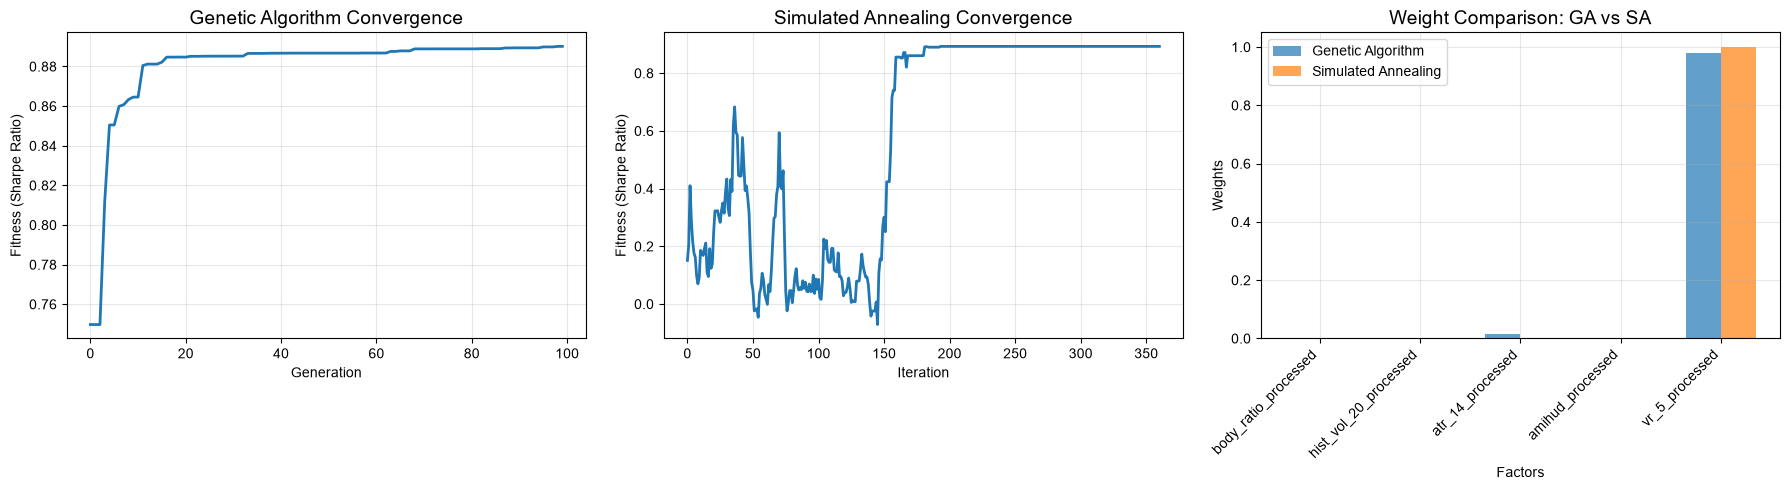

优化对比图已保存到: output1/optimization_comparison.png

策略总结

1. 数据准备:
   - 原始数据: 23979 条记录
   - 股票数量: 100 只
   - 时间范围: 2024-01-02 00:00:00 至 2025-01-10 00:00:00

2. 因子计算:
   - 总因子数: 52
   - 最终选择因子: 8

3. 策略表现:
   - IR加权策略年化收益: 283.22%
   - IR加权策略夏普比率: 4.8118
   - 等权策略年化收益: 164.65%
   - 等权策略夏普比率: 3.3493

4. 权重优化:
   - 遗传算法最优夏普: 0.8901
   - 模拟退火最优夏普: 0.8929

分析完成！所有结果已保存到 output 文件夹。


In [24]:
# 6.1 获取因子收益序列（Brinson归因）
print("\n6.1 计算因子收益序列...")

def calculate_factor_returns(df, factor_cols):
    """计算因子收益序列（简化版Brinson归因）"""
    factor_returns = {}
    
    for col in factor_cols:
        daily_betas = []
        daily_dates = []
        
        for date in df['trade_date'].unique():
            day_data = df[df['trade_date'] == date].dropna(subset=[col, 'daily_return'])
            if len(day_data) < 10:
                continue
            
            try:
                X = day_data[col].values.reshape(-1, 1)
                y = day_data['daily_return'].values
                X = np.column_stack([np.ones(len(X)), X])
                
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                daily_betas.append(beta[1])
                daily_dates.append(date)
            except:
                continue
        
        if len(daily_betas) > 0:
            factor_returns[col] = pd.Series(daily_betas, index=pd.to_datetime(daily_dates))
    
    return factor_returns

# 使用最终选择的因子
if len(final_factors) > 0:
    print(f"使用 {min(5, len(final_factors))} 个因子进行优化")
    factor_returns_dict = calculate_factor_returns(df, final_factors[:min(5, len(final_factors))])
    
    if len(factor_returns_dict) > 0:
        factor_returns_df = pd.DataFrame(factor_returns_dict)
        factor_returns_df = factor_returns_df.dropna()
        print(f"因子收益矩阵形状: {factor_returns_df.shape}")
        print("\n因子收益统计:")
        print(factor_returns_df.describe())
        
        # 保存因子收益序列
        factor_returns_df.to_csv(os.path.join(output_dir, 'factor_returns_series.csv'))
        print(f"因子收益序列已保存到: {output_dir}/factor_returns_series.csv")
        
        # 6.2 目标函数：最大化夏普比率
        print("\n6.2 优化目标：最大化夏普比率...")
        
        def negative_sharpe(weights, returns_matrix):
            """负夏普比率（用于最小化）"""
            weights = np.array(weights)
            portfolio_return = np.sum(returns_matrix.mean() * weights)
            portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns_matrix.cov(), weights)))
            sharpe = portfolio_return / (portfolio_volatility + 1e-6)
            return -sharpe
        
        # 检查协方差矩阵的正定性
        print("\n检查协方差矩阵正定性...")
        cov_matrix = factor_returns_df.cov()
        eigenvalues = eigh(cov_matrix)[0]
        is_positive_definite = np.all(eigenvalues > 1e-6)
        print(f"协方差矩阵是否正定: {is_positive_definite}")
        
        if not is_positive_definite:
            print("协方差矩阵非正定，进行正则化处理...")
            cov_matrix = cov_matrix + np.eye(len(cov_matrix)) * 1e-6
        
        # 6.3 非凸优化方法对比
        print("\n6.3 非凸优化方法对比...")
        
        # 遗传算法
        print("\n实现遗传算法...")
        def genetic_algorithm(returns_matrix, n_population=50, n_generations=100, mutation_rate=0.1):
            """遗传算法优化权重"""
            n_factors = returns_matrix.shape[1]
            
            # 初始化种群
            population = np.random.dirichlet(np.ones(n_factors), size=n_population)
            fitness_history = []
            best_weights_history = []
            
            for generation in range(n_generations):
                # 计算适应度
                fitness = np.array([-negative_sharpe(ind, returns_matrix) for ind in population])
                
                # 记录最优
                best_idx = np.argmax(fitness)
                best_weights = population[best_idx].copy()
                best_fitness = fitness[best_idx]
                fitness_history.append(best_fitness)
                best_weights_history.append(best_weights)
                
                # 选择（轮盘赌）
                selected = []
                for _ in range(n_population):
                    # 随机选择两个个体进行锦标赛
                    idx1 = np.random.randint(n_population)
                    idx2 = np.random.randint(n_population)
                    # 选择适应度更高的个体
                    if fitness[idx1] > fitness[idx2]:
                        selected.append(population[idx1].copy())
                    else:
                        selected.append(population[idx2].copy())
                selected = np.array(selected)
                
                # 交叉
                offspring = []
                for i in range(0, n_population, 2):
                    if i+1 < n_population:
                        parent1 = selected[i]
                        parent2 = selected[i+1]
                        # 均匀交叉
                        mask = np.random.random(n_factors) > 0.5
                        child1 = parent1 * mask + parent2 * (1 - mask)
                        child2 = parent2 * mask + parent1 * (1 - mask)
                        # 确保和为1
                        child1 = child1 / (child1.sum() + 1e-6)
                        child2 = child2 / (child2.sum() + 1e-6)
                        offspring.extend([child1, child2])
                
                # 变异
                for i in range(len(offspring)):
                    if np.random.random() < mutation_rate:
                        # 随机变异
                        idx = np.random.randint(n_factors)
                        offspring[i][idx] = np.random.random()
                        offspring[i] = offspring[i] / (offspring[i].sum() + 1e-6)
                
                # 精英保留
                n_elite = max(1, int(0.1 * n_population))
                elite_idx = np.argsort(fitness)[-n_elite:]
                elite = population[elite_idx]
                
                # 新种群
                population = np.vstack([elite, np.array(offspring[:n_population - n_elite])])
            
            # 返回最优权重
            final_fitness = np.array([-negative_sharpe(ind, returns_matrix) for ind in population])
            best_idx = np.argmax(final_fitness)
            return population[best_idx], fitness_history
        
        # 模拟退火
        print("\n实现模拟退火...")
        def simulated_annealing(returns_matrix, n_iterations=5000, initial_temp=100, cooling_rate=0.95):
            """模拟退火算法优化权重"""
            n_factors = returns_matrix.shape[1]
            
            # 初始解（等权）
            current_weights = np.ones(n_factors) / n_factors
            current_sharpe = -negative_sharpe(current_weights, returns_matrix)
            best_weights = current_weights.copy()
            best_sharpe = current_sharpe
            sharpe_history = [current_sharpe]
            
            temp = initial_temp
            
            for iteration in range(n_iterations):
                # 生成邻域解
                new_weights = current_weights + np.random.normal(0, 0.1, n_factors)
                new_weights = np.maximum(new_weights, 0)
                new_weights = new_weights / (new_weights.sum() + 1e-6)
                
                new_sharpe = -negative_sharpe(new_weights, returns_matrix)
                delta = new_sharpe - current_sharpe
                
                # 接受准则
                if delta > 0 or np.random.random() < np.exp(delta / (temp + 1e-6)):
                    current_weights = new_weights
                    current_sharpe = new_sharpe
                    
                    if new_sharpe > best_sharpe:
                        best_weights = new_weights.copy()
                        best_sharpe = new_sharpe
                
                sharpe_history.append(current_sharpe)
                
                # 降温
                temp *= cooling_rate
                
                # 可选：提前终止
                if temp < 1e-6:
                    break
            
            return best_weights, sharpe_history
        
        # 运行遗传算法
        print("\n运行遗传算法优化...")
        ga_weights, ga_fitness = genetic_algorithm(factor_returns_df)
        
        # 运行模拟退火
        print("\n运行模拟退火优化...")
        sa_weights, sa_fitness = simulated_annealing(factor_returns_df)
        
        # 比较结果
        print("\n6.4 优化结果对比...")
        print("\n遗传算法最优权重:")
        ga_weights_dict = {}
        for i, col in enumerate(factor_returns_df.columns):
            print(f"{col}: {ga_weights[i]:.4f}")
            ga_weights_dict[col] = ga_weights[i]
        ga_sharpe = -negative_sharpe(ga_weights, factor_returns_df)
        print(f"最优夏普比率: {ga_sharpe:.4f}")
        
        print("\n模拟退火最优权重:")
        sa_weights_dict = {}
        for i, col in enumerate(factor_returns_df.columns):
            print(f"{col}: {sa_weights[i]:.4f}")
            sa_weights_dict[col] = sa_weights[i]
        sa_sharpe = -negative_sharpe(sa_weights, factor_returns_df)
        print(f"最优夏普比率: {sa_sharpe:.4f}")
        
        if metrics_ir:
            print(f"\nIR加权策略夏普比率: {metrics_ir['sharpe_ratio']:.4f}")
        
        # 保存优化结果
        optimization_results = pd.DataFrame({
            'factor': list(ga_weights_dict.keys()),
            'ga_weights': list(ga_weights_dict.values()),
            'sa_weights': list(sa_weights_dict.values())
        })
        optimization_results.to_csv(os.path.join(output_dir, 'optimization_weights.csv'), index=False)
        print(f"优化权重已保存到: {output_dir}/optimization_weights.csv")
        
        # 绘制优化过程对比
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 遗传算法收敛
        axes[0].plot(ga_fitness, linewidth=2)
        axes[0].set_title('Genetic Algorithm Convergence', fontsize=14)
        axes[0].set_xlabel('Generation')
        axes[0].set_ylabel('Fitness (Sharpe Ratio)')
        axes[0].grid(True, alpha=0.3)
        
        # 模拟退火收敛
        axes[1].plot(sa_fitness, linewidth=2)
        axes[1].set_title('Simulated Annealing Convergence', fontsize=14)
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Fitness (Sharpe Ratio)')
        axes[1].grid(True, alpha=0.3)
        
        # 权重对比
        x = np.arange(len(factor_returns_df.columns))
        width = 0.35
        axes[2].bar(x - width/2, ga_weights, width, label='Genetic Algorithm', alpha=0.7)
        axes[2].bar(x + width/2, sa_weights, width, label='Simulated Annealing', alpha=0.7)
        axes[2].set_xlabel('Factors')
        axes[2].set_ylabel('Weights')
        axes[2].set_title('Weight Comparison: GA vs SA', fontsize=14)
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(factor_returns_df.columns, rotation=45, ha='right')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'optimization_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"优化对比图已保存到: {output_dir}/optimization_comparison.png")
        
    else:
        print("没有足够的因子收益数据用于优化")
else:
    print("没有选中的因子可用于优化")

# 总结
print("\n" + "="*80)
print("策略总结")
print("="*80)

print("\n1. 数据准备:")
print(f"   - 原始数据: {len(df)} 条记录")
print(f"   - 股票数量: {df['ts_code'].nunique()} 只")
print(f"   - 时间范围: {df['trade_date'].min()} 至 {df['trade_date'].max()}")

print("\n2. 因子计算:")
print(f"   - 总因子数: {len(factor_columns)}")
print(f"   - 最终选择因子: {len(final_factors)}")

if metrics_ir:
    print("\n3. 策略表现:")
    print(f"   - IR加权策略年化收益: {metrics_ir['annual_return']:.2%}")
    print(f"   - IR加权策略夏普比率: {metrics_ir['sharpe_ratio']:.4f}")
    
if metrics_equal:
    print(f"   - 等权策略年化收益: {metrics_equal['annual_return']:.2%}")
    print(f"   - 等权策略夏普比率: {metrics_equal['sharpe_ratio']:.4f}")

if len(final_factors) > 0 and len(factor_returns_dict) > 0:
    print("\n4. 权重优化:")
    print(f"   - 遗传算法最优夏普: {ga_sharpe:.4f}")
    print(f"   - 模拟退火最优夏普: {sa_sharpe:.4f}")

print("\n" + "="*80)
print("分析完成！所有结果已保存到 output 文件夹。")
print("="*80)


7. 优化权重策略回测与对比

7.1 使用优化后的权重合成综合因子...
优化权重已存在，开始合成综合因子...

Genetic Algorithm Weights: {'body_ratio_processed': np.float64(0.00041046180318310833), 'hist_vol_20_processed': np.float64(0.0006599637927718679), 'atr_14_processed': np.float64(0.01568853475133394), 'amihud_processed': np.float64(0.002469585148073338), 'vr_5_processed': np.float64(0.9807704535876421)}
Simulated Annealing Weights: {'body_ratio_processed': np.float64(0.0), 'hist_vol_20_processed': np.float64(0.0), 'atr_14_processed': np.float64(0.0), 'amihud_processed': np.float64(0.0), 'vr_5_processed': np.float64(0.9999990558515773)}

Optimized Composite Score Statistics:
       composite_score_ga  composite_score_sa
count        2.397900e+04        2.397900e+04
mean        -1.108232e-16       -1.161570e-16
std          9.582994e-01        9.774300e-01
min         -2.506267e+00       -2.549607e+00
25%         -6.743439e-01       -6.884507e-01
50%         -1.611017e-01       -1.637707e-01
75%          4.947411e-01        5.05

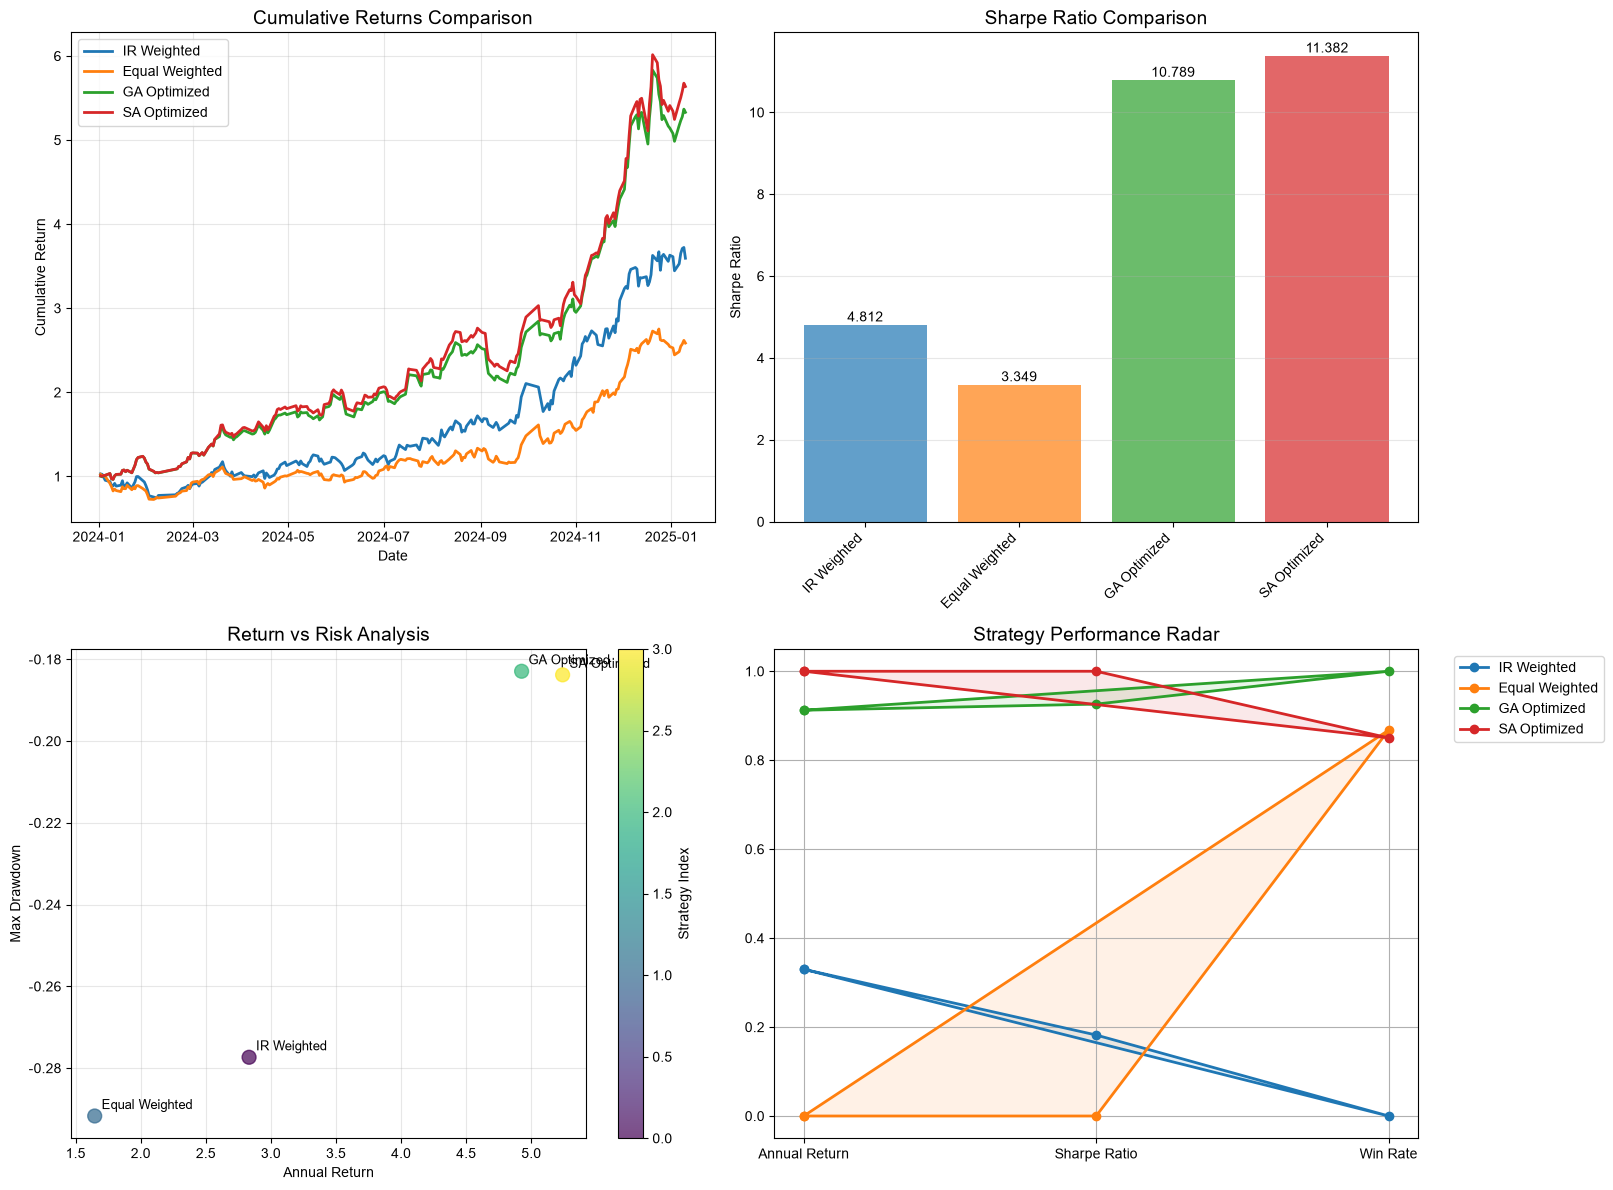

Strategy comparison chart saved to: output1/strategy_comparison.png

7.6 Rolling Sharpe Ratio Comparison...


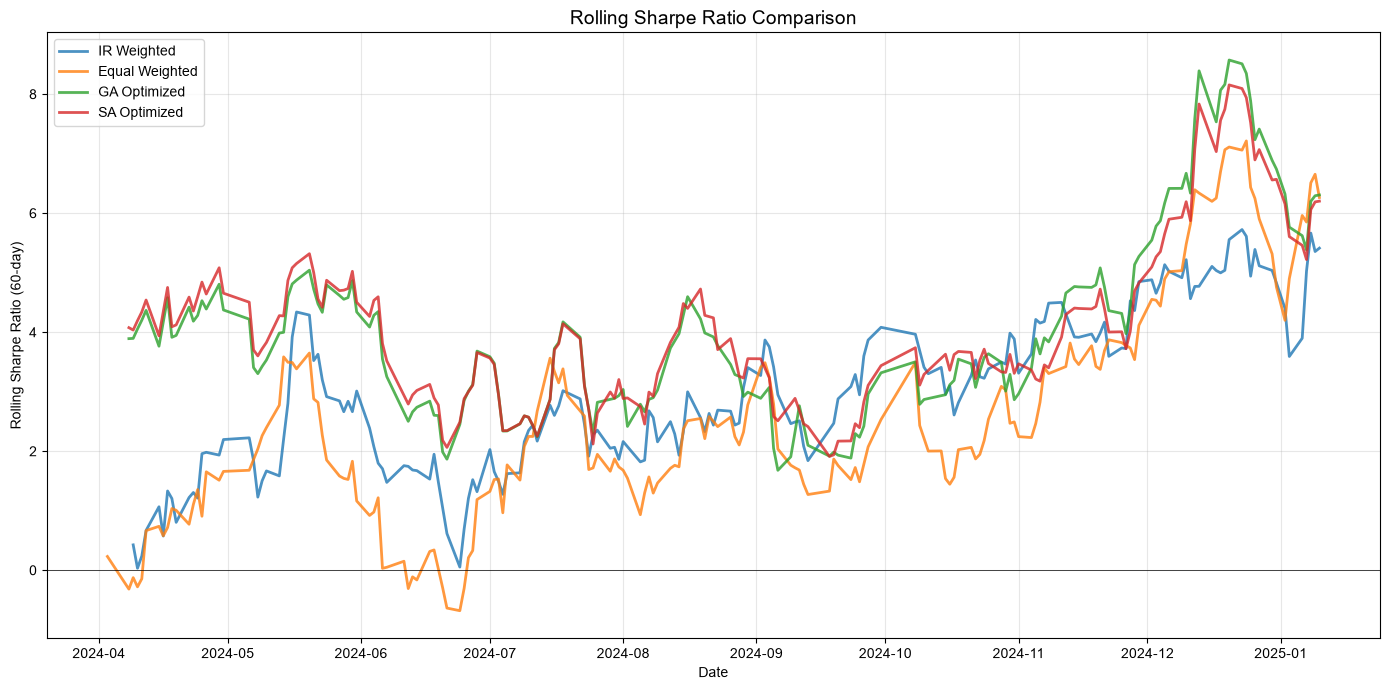

Rolling Sharpe ratio comparison saved to: output1/rolling_sharpe_comparison.png

7.7 Drawdown Comparison...


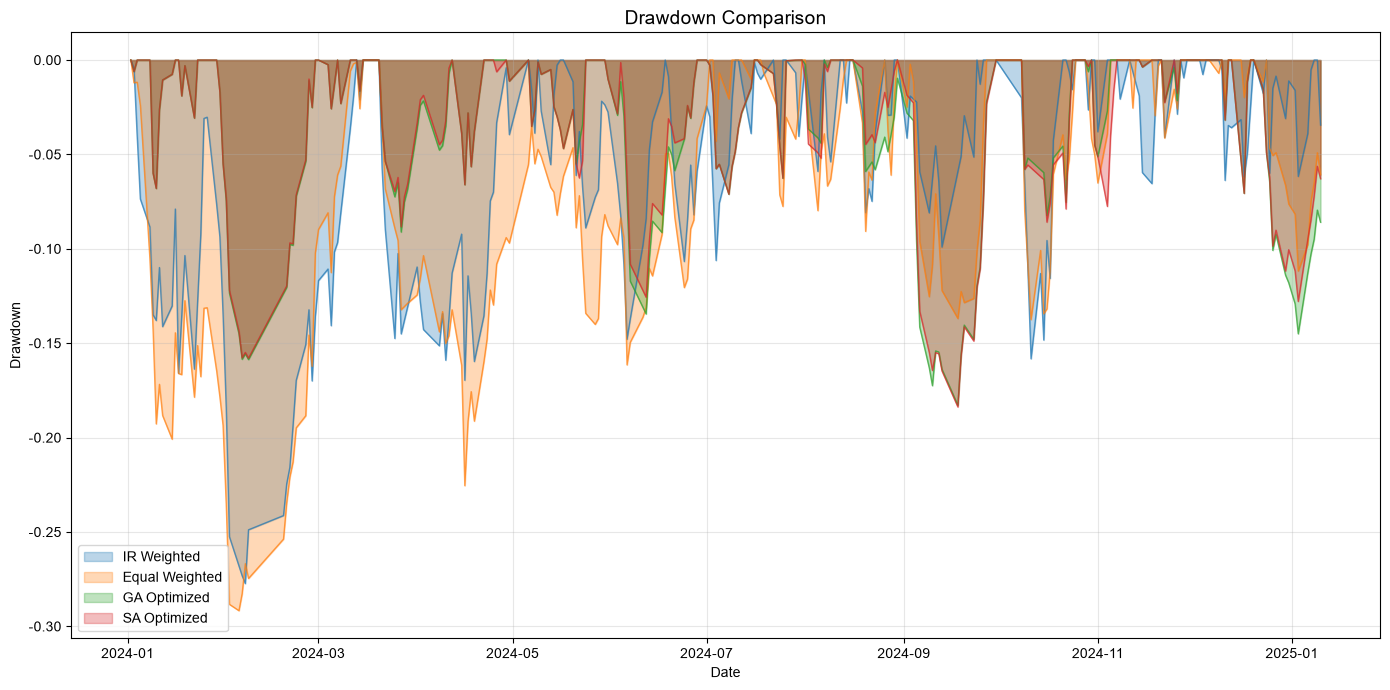

Drawdown comparison saved to: output1/drawdown_comparison.png

7.8 Optimization Results Summary

Optimized Weights Comparison:
GA Optimal Weights: {'body_ratio_processed': np.float64(0.00041046180318310833), 'hist_vol_20_processed': np.float64(0.0006599637927718679), 'atr_14_processed': np.float64(0.01568853475133394), 'amihud_processed': np.float64(0.002469585148073338), 'vr_5_processed': np.float64(0.9807704535876421)}
GA Optimal Sharpe Ratio: 0.8901
SA Optimal Weights: {'body_ratio_processed': np.float64(0.0), 'hist_vol_20_processed': np.float64(0.0), 'atr_14_processed': np.float64(0.0), 'amihud_processed': np.float64(0.0), 'vr_5_processed': np.float64(0.9999990558515773)}
SA Optimal Sharpe Ratio: 0.8929

Strategy Performance Summary:
                Total Return  Annual Return  Volatility  Sharpe Ratio  \
IR Weighted           2.5947         2.8322      0.5886        4.8118   
Equal Weighted        1.5858         1.6465      0.4916        3.3493   
GA Optimized          4.3301     

In [25]:
# ==================== 7. 优化权重策略回测与对比 ====================
print("\n" + "="*80)
print("7. 优化权重策略回测与对比")
print("="*80)

# 7.1 使用优化后的权重合成综合因子
print("\n7.1 使用优化后的权重合成综合因子...")

# 检查优化权重是否存在
if 'ga_weights' in locals() and 'sa_weights' in locals():
    print("优化权重已存在，开始合成综合因子...")
    
    # 创建优化权重字典
    ga_weights_dict = {}
    sa_weights_dict = {}
    for i, col in enumerate(factor_returns_df.columns):
        ga_weights_dict[col] = ga_weights[i]
        sa_weights_dict[col] = sa_weights[i]
    
    print(f"\nGenetic Algorithm Weights: {ga_weights_dict}")
    print(f"Simulated Annealing Weights: {sa_weights_dict}")
    
    # 合成优化后的综合因子
    df['composite_score_ga'] = composite_score(df, ga_weights_dict)
    df['composite_score_sa'] = composite_score(df, sa_weights_dict)
    
    print("\nOptimized Composite Score Statistics:")
    print(df[['composite_score_ga', 'composite_score_sa']].describe())
    
    # 7.2 使用优化权重进行选股
    print("\n7.2 使用优化权重进行选股...")
    
    # 初始化回测数据
    df['selected_ga'] = 0
    df['selected_sa'] = 0
    
    print("开始选股...")
    for date, group in df.groupby('year_month'):
        if len(group) < 30:
            continue
        
        # 限制每个聚类最多30%
        cluster_limit = max(1, int(0.3 * 30))
        
        selected_stocks_ga = []
        selected_stocks_sa = []
        
        for cluster in group['cluster'].unique():
            cluster_group = group[group['cluster'] == cluster]
            # 选择该聚类中得分最高的股票
            top_n_ga = min(cluster_limit, len(cluster_group))
            top_n_sa = min(cluster_limit, len(cluster_group))
            
            top_ga = cluster_group.nlargest(top_n_ga, 'composite_score_ga')
            top_sa = cluster_group.nlargest(top_n_sa, 'composite_score_sa')
            
            selected_stocks_ga.extend(top_ga.index.tolist())
            selected_stocks_sa.extend(top_sa.index.tolist())
        
        # 如果选股不足30，从剩余股票中补充
        if len(selected_stocks_ga) < 30:
            remaining = group[~group.index.isin(selected_stocks_ga)]
            if len(remaining) > 0:
                additional = remaining.nlargest(30 - len(selected_stocks_ga), 'composite_score_ga')
                selected_stocks_ga.extend(additional.index.tolist())
        
        if len(selected_stocks_sa) < 30:
            remaining = group[~group.index.isin(selected_stocks_sa)]
            if len(remaining) > 0:
                additional = remaining.nlargest(30 - len(selected_stocks_sa), 'composite_score_sa')
                selected_stocks_sa.extend(additional.index.tolist())
        
        # 标记选中的股票
        if len(selected_stocks_ga) > 0:
            df.loc[selected_stocks_ga, 'selected_ga'] = 1
        if len(selected_stocks_sa) > 0:
            df.loc[selected_stocks_sa, 'selected_sa'] = 1
    
    print("Stock selection completed")
    print(f"GA Strategy selected records: {df['selected_ga'].sum()}")
    print(f"SA Strategy selected records: {df['selected_sa'].sum()}")
    
    # 7.3 回测优化策略
    print("\n7.3 回测优化策略...")
    
    # 回测GA优化策略
    print("\n7.3.1 Genetic Algorithm Optimized Strategy Backtest...")
    returns_ga, cum_ga, metrics_ga = backtest_strategy(df, 'selected_ga', 'GA Optimized Strategy')
    
    # 回测SA优化策略
    print("\n7.3.2 Simulated Annealing Optimized Strategy Backtest...")
    returns_sa, cum_sa, metrics_sa = backtest_strategy(df, 'selected_sa', 'SA Optimized Strategy')
    
    # 7.4 所有策略对比
    print("\n7.4 Strategy Performance Comparison...")
    
    # 收集所有策略的绩效指标
    all_metrics = []
    strategy_names = []
    
    if metrics_ir:
        all_metrics.append(metrics_ir)
        strategy_names.append('IR Weighted')
    if metrics_equal:
        all_metrics.append(metrics_equal)
        strategy_names.append('Equal Weighted')
    if metrics_ga:
        all_metrics.append(metrics_ga)
        strategy_names.append('GA Optimized')
    if metrics_sa:
        all_metrics.append(metrics_sa)
        strategy_names.append('SA Optimized')
    
    if len(all_metrics) > 0:
        # 创建对比DataFrame
        compare_df = pd.DataFrame(all_metrics, index=strategy_names)
        compare_df = compare_df[['total_return', 'annual_return', 'volatility', 'sharpe_ratio', 'max_drawdown', 'win_rate']]
        compare_df.columns = ['Total Return', 'Annual Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown', 'Win Rate']
        
        print("\nStrategy Performance Comparison:")
        print(compare_df.round(4))
        
        # 保存对比结果
        compare_df.to_csv(os.path.join(output_dir, 'strategy_comparison.csv'))
        print(f"\nComparison results saved to: {output_dir}/strategy_comparison.csv")
        
        # 7.5 绘制策略对比图表
        print("\n7.5 Plotting strategy comparison charts...")
        
        # 图1：累积收益对比
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Cumulative returns comparison
        ax1 = axes[0, 0]
        if cum_ir is not None:
            ax1.plot(cum_ir.index, cum_ir, label='IR Weighted', linewidth=2)
        if cum_equal is not None:
            ax1.plot(cum_equal.index, cum_equal, label='Equal Weighted', linewidth=2)
        if cum_ga is not None:
            ax1.plot(cum_ga.index, cum_ga, label='GA Optimized', linewidth=2)
        if cum_sa is not None:
            ax1.plot(cum_sa.index, cum_sa, label='SA Optimized', linewidth=2)
        ax1.set_title('Cumulative Returns Comparison', fontsize=14)
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Cumulative Return')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Sharpe ratio comparison (bar chart)
        ax2 = axes[0, 1]
        sharpe_values = compare_df['Sharpe Ratio'].values
        colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        bars = ax2.bar(range(len(sharpe_values)), sharpe_values, color=colors_bar[:len(sharpe_values)], alpha=0.7)
        ax2.set_xticks(range(len(sharpe_values)))
        ax2.set_xticklabels(compare_df.index, rotation=45, ha='right')
        ax2.set_ylabel('Sharpe Ratio')
        ax2.set_title('Sharpe Ratio Comparison', fontsize=14)
        ax2.grid(True, alpha=0.3, axis='y')
        # 添加数值标签
        for bar, value in zip(bars, sharpe_values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{value:.3f}', ha='center', va='bottom', fontsize=10)
        
        # Annual return vs max drawdown (scatter plot)
        ax3 = axes[1, 0]
        annual_returns = compare_df['Annual Return'].values
        max_drawdowns = compare_df['Max Drawdown'].values
        scatter = ax3.scatter(annual_returns, max_drawdowns, s=100, c=range(len(annual_returns)), 
                             cmap='viridis', alpha=0.7)
        # 添加标签
        for i, name in enumerate(compare_df.index):
            ax3.annotate(name, (annual_returns[i], max_drawdowns[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
        ax3.set_xlabel('Annual Return')
        ax3.set_ylabel('Max Drawdown')
        ax3.set_title('Return vs Risk Analysis', fontsize=14)
        ax3.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax3, label='Strategy Index')
        
        # Performance radar chart
        ax4 = axes[1, 1]
        # 标准化指标用于雷达图
        metrics_for_radar = ['Annual Return', 'Sharpe Ratio', 'Win Rate']
        radar_data = compare_df[metrics_for_radar].copy()
        # 对每个指标进行归一化（0-1）
        for col in radar_data.columns:
            min_val = radar_data[col].min()
            max_val = radar_data[col].max()
            if max_val > min_val:
                radar_data[col] = (radar_data[col] - min_val) / (max_val - min_val)
            else:
                radar_data[col] = 0.5
        
        # 绘制雷达图
        angles = np.linspace(0, 2 * np.pi, len(metrics_for_radar), endpoint=False).tolist()
        angles += angles[:1]  # 闭合
        
        colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        for idx, name in enumerate(radar_data.index):
            values = radar_data.iloc[idx].values.tolist()
            values += values[:1]  # 闭合
            ax4.plot(angles, values, 'o-', linewidth=2, label=name, 
                    color=colors_radar[idx % len(colors_radar)])
            ax4.fill(angles, values, alpha=0.1, color=colors_radar[idx % len(colors_radar)])
        
        ax4.set_xticks(angles[:-1])
        ax4.set_xticklabels(metrics_for_radar)
        ax4.set_title('Strategy Performance Radar', fontsize=14)
        ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax4.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'strategy_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Strategy comparison chart saved to: {output_dir}/strategy_comparison.png")
        
        # 7.6 滚动夏普比率对比
        print("\n7.6 Rolling Sharpe Ratio Comparison...")
        
        fig, ax = plt.subplots(figsize=(14, 7))
        
        if returns_ir is not None:
            rolling_sharpe_ir = returns_ir.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
            ax.plot(rolling_sharpe_ir.index, rolling_sharpe_ir, label='IR Weighted', linewidth=2, alpha=0.8)
        
        if returns_equal is not None:
            rolling_sharpe_equal = returns_equal.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
            ax.plot(rolling_sharpe_equal.index, rolling_sharpe_equal, label='Equal Weighted', linewidth=2, alpha=0.8)
        
        if returns_ga is not None:
            rolling_sharpe_ga = returns_ga.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
            ax.plot(rolling_sharpe_ga.index, rolling_sharpe_ga, label='GA Optimized', linewidth=2, alpha=0.8)
        
        if returns_sa is not None:
            rolling_sharpe_sa = returns_sa.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
            ax.plot(rolling_sharpe_sa.index, rolling_sharpe_sa, label='SA Optimized', linewidth=2, alpha=0.8)
        
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.set_xlabel('Date')
        ax.set_ylabel('Rolling Sharpe Ratio (60-day)')
        ax.set_title('Rolling Sharpe Ratio Comparison', fontsize=14)
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'rolling_sharpe_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Rolling Sharpe ratio comparison saved to: {output_dir}/rolling_sharpe_comparison.png")
        
        # 7.7 回撤对比
        print("\n7.7 Drawdown Comparison...")
        
        fig, ax = plt.subplots(figsize=(14, 7))
        
        if cum_ir is not None:
            rolling_max_ir = cum_ir.expanding().max()
            drawdown_ir = (cum_ir - rolling_max_ir) / rolling_max_ir
            ax.fill_between(drawdown_ir.index, drawdown_ir, 0, alpha=0.3, label='IR Weighted', color='#1f77b4')
            ax.plot(drawdown_ir.index, drawdown_ir, linewidth=1, color='#1f77b4', alpha=0.7)
        
        if cum_equal is not None:
            rolling_max_equal = cum_equal.expanding().max()
            drawdown_equal = (cum_equal - rolling_max_equal) / rolling_max_equal
            ax.fill_between(drawdown_equal.index, drawdown_equal, 0, alpha=0.3, label='Equal Weighted', color='#ff7f0e')
            ax.plot(drawdown_equal.index, drawdown_equal, linewidth=1, color='#ff7f0e', alpha=0.7)
        
        if cum_ga is not None:
            rolling_max_ga = cum_ga.expanding().max()
            drawdown_ga = (cum_ga - rolling_max_ga) / rolling_max_ga
            ax.fill_between(drawdown_ga.index, drawdown_ga, 0, alpha=0.3, label='GA Optimized', color='#2ca02c')
            ax.plot(drawdown_ga.index, drawdown_ga, linewidth=1, color='#2ca02c', alpha=0.7)
        
        if cum_sa is not None:
            rolling_max_sa = cum_sa.expanding().max()
            drawdown_sa = (cum_sa - rolling_max_sa) / rolling_max_sa
            ax.fill_between(drawdown_sa.index, drawdown_sa, 0, alpha=0.3, label='SA Optimized', color='#d62728')
            ax.plot(drawdown_sa.index, drawdown_sa, linewidth=1, color='#d62728', alpha=0.7)
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Drawdown')
        ax.set_title('Drawdown Comparison', fontsize=14)
        ax.legend(loc='lower left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'drawdown_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Drawdown comparison saved to: {output_dir}/drawdown_comparison.png")
        
        # 7.8 总结报告
        print("\n" + "="*80)
        print("7.8 Optimization Results Summary")
        print("="*80)
        
        print("\nOptimized Weights Comparison:")
        print(f"GA Optimal Weights: {ga_weights_dict}")
        print(f"GA Optimal Sharpe Ratio: {ga_sharpe:.4f}")
        print(f"SA Optimal Weights: {sa_weights_dict}")
        print(f"SA Optimal Sharpe Ratio: {sa_sharpe:.4f}")
        
        print("\nStrategy Performance Summary:")
        print(compare_df.round(4))
        
        # 找出最佳策略
        best_sharpe_idx = compare_df['Sharpe Ratio'].idxmax()
        best_return_idx = compare_df['Annual Return'].idxmax()
        best_risk_idx = compare_df['Max Drawdown'].idxmin()
        
        print(f"\n最佳夏普比率策略: {best_sharpe_idx} ({compare_df.loc[best_sharpe_idx, 'Sharpe Ratio']:.4f})")
        print(f"最佳年化收益策略: {best_return_idx} ({compare_df.loc[best_return_idx, 'Annual Return']:.2%})")
        print(f"最低回撤策略: {best_risk_idx} ({compare_df.loc[best_risk_idx, 'Max Drawdown']:.2%})")
        
        print("\n" + "="*80)
        print("All analysis completed!")
        print(f"All output files saved to: {output_dir}/")
        print("="*80)

else:
    print("优化权重不存在，请先运行第6部分进行权重优化！")